### References:
Symlib docs: https://web.stanford.edu/group/gfc/gfcsims/build/html/symlib_documentation.html#symlib.scale_factors

### TODO:

- Normalize by m200c
- Fit Diemer density profile
- Fit two power-law density profiles
- Charcterize BFE residuals 

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
plt.style.use("../../MW_viz/matplotlib.mplstyle")

In [19]:
np.e**2

7.3890560989306495

In [70]:
def diemer22_profile(x, alpha=0.15, beta=4.0, rs=0.2, rt=1.0):
    S = -2.0/alpha * ((x/rs)**alpha - 1.0) - (1.0/beta) * ((x/rt)**beta - (rs/rt)**beta)
    return np.exp(S)

def diemer22_M(x, alpha=0.15, beta=4.0, rs=0.2, rt=1.0):
    S = -2.0/alpha * ((x/rs)**alpha - 1.0) - 1.0/beta * ((x/rt)**beta - (rs/rt)**beta)
    return np.exp(S) * x**2

In [78]:
I = quad(diemer22_profile, 0, 1)[0]
print(I)

10.124157711068626


In [72]:
np.mean(diemer22_profile(rbins, alpha=0.15, beta=4.0, rs=0.2, rt=R))

40158.88737155569

In [114]:
diemer22_profile(0.2, alpha=0.15, beta=4.0, rs=0.2, rt=1)

1.0

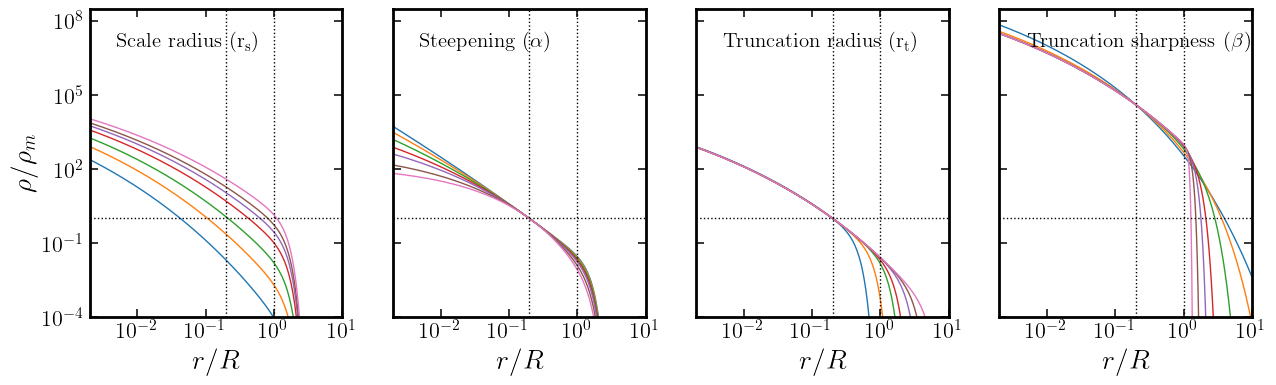

In [115]:
R=1
rbins = np.logspace(-8, np.log10(10*R), 1000)
rs_arr = np.array([0.02*R, 0.05*R, 0.1*R, 0.2*R, 0.3*R, 0.4*R, 0.6*R])
alpha_arr = np.array([0.03, 0.06, 0.1, 0.15, 0.2, 0.3, 0.4])
rt_arr = np.array([0.3*R, 0.5*R, 0.8*R, 1.0*R, 1.5*R, 2.0*R, 3*R])
beta_arr = np.array([0.5, 1, 2, 4, 6, 10, 20])
fig, ax = plt.subplots(1, 4, figsize=((15, 4)),sharey=True)

ax[0].text(5e-3, 1e7, r'$\rm{Scale\ radius\ } (r_s)$', fontsize=15)
for rs in range(len(rs_arr)):
    ax[0].loglog(rbins, diemer22_profile(rbins, alpha=0.15, beta=4.0, rs=rs_arr[rs], rt=R)/0.2, lw=1)

ax[1].text(5e-3, 1e7, r'$\rm{Steepening\ (\alpha)}$', fontsize=15)
for ais in range(len(alpha_arr)):
    ax[1].loglog(rbins, diemer22_profile(rbins, alpha=alpha_arr[ais], beta=4.0, rs=0.2, rt=R), lw=1)

ax[2].text(5e-3, 1e7, r'$\rm{Truncation\ radius\ } (r_t)$', fontsize=15)
for RT in range(len(rt_arr)):
    ax[2].loglog(rbins, diemer22_profile(rbins, alpha=0.15, beta=4.0, rs=0.2, rt=rt_arr[RT]), lw=1)

ax[3].text(5e-3, 1e7, r'$\rm{Truncation\ sharpness\ } (\beta)$', fontsize=15)
for B in range(len(beta_arr)):
    ax[3].loglog(rbins, diemer22_profile(rbins, alpha=0.15, beta=beta_arr[B], rs=0.2, rt=R)*40158, lw=1)


ax[0].set_ylim(1e-4, 3e8)
ax[0].set_ylabel(r'$\rho/\rho_m$')


for i in range(4):
    ax[i].set_xlabel(r'$r/R$')
    ax[i].set_xlim(2e-3, 10)
    ax[i].axvline(0.2*R, lw=1, ls=':', c='k')
    ax[i].axhline(1.0, lw=1, ls=':', c='k')
    ax[i].axvline(R, lw=1, ls=':', c='k')
    ax[i].set_xticks([0.01, 0.1, 1, 10])
    ax[i].set_yticks([1e-4, 1e-1, 1e2, 1e5, 1e8])

plt.show()

In [10]:
data = np.loadtxt("./halo_004_density_profile.txt")
data_smooth = np.loadtxt("./halo_004_density_profile_smooth.txt")

In [11]:
Mvir, Rvir = np.loadtxt("./halo_004_Mvir_Rvir.txt", unpack=True)

In [12]:
edges = np.logspace(0.1, 2.5, 101)[:-1]

In [13]:
cmap = plt.cm.get_cmap('Blues')


/tmp/ipykernel_1964579/2663837186.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')


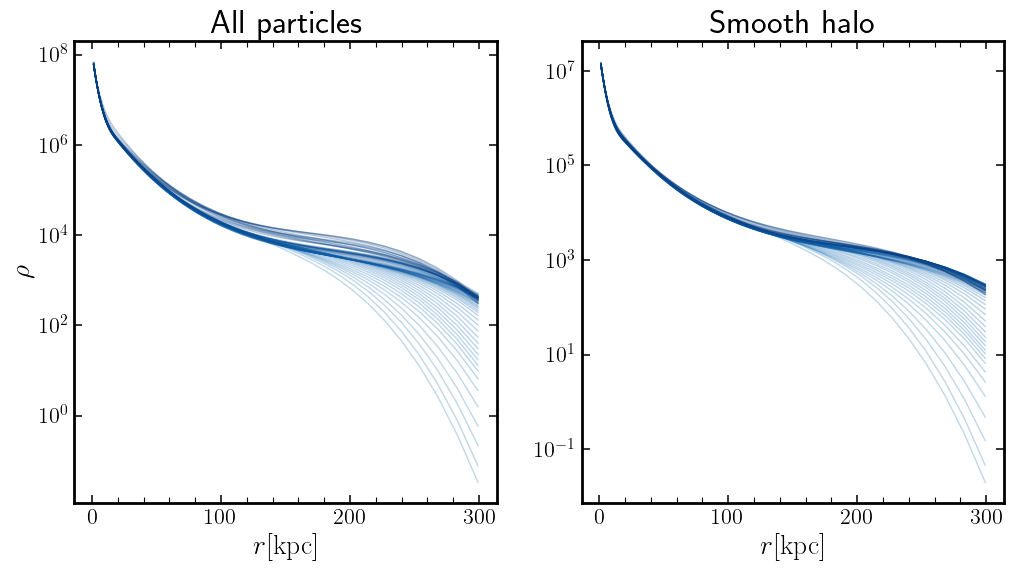

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for i in range(0, 244):
    im = ax[0].semilogy(edges, data[i], c=cmap(i), alpha=0.3, lw=1)
    ax[1].semilogy(edges, data_smooth[i], c=cmap(i), alpha=0.3, lw=1)
ax[0].set_xlabel(r'$r\rm{ [kpc]}$')
ax[0].set_ylabel(r'$\rho$')
ax[1].set_xlabel(r'$r\rm{ [kpc]}$')
ax[0].set_title('All particles')
ax[1].set_title('Smooth halo')

plt.show()

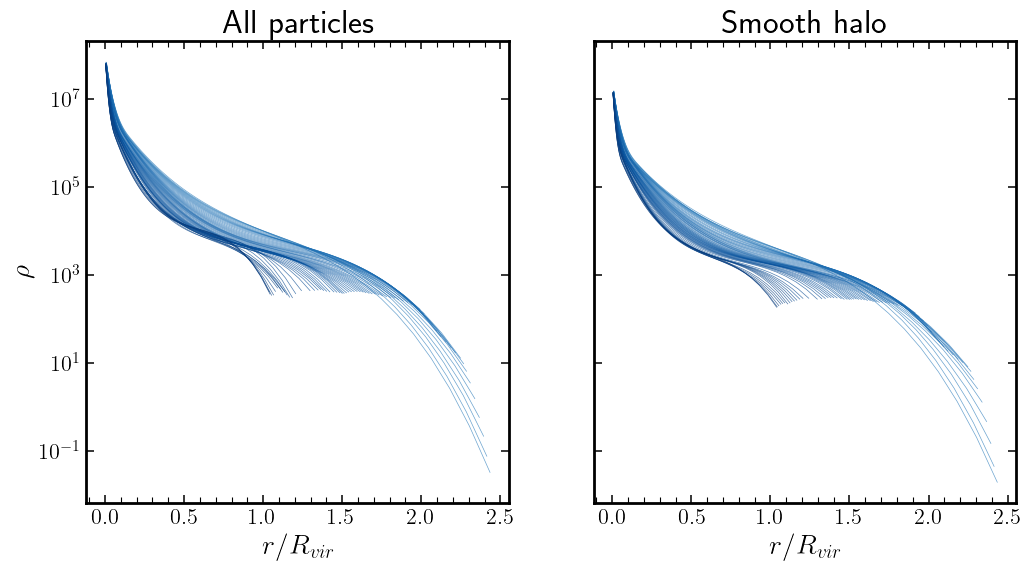

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for i in range(244):
    ax[0].semilogy(edges/Rvir[i], data[i], c=cmap(i), alpha=0.7, lw=0.5)
    ax[1].semilogy(edges/Rvir[i], data_smooth[i], c=cmap(i), alpha=0.7, lw=0.5)
ax[1].set_xlabel(r'$r/R_{vir}$')
ax[0].set_xlabel(r'$r/R_{vir}$')

ax[0].set_ylabel(r'$\rho$')
ax[0].set_title('All particles')
ax[1].set_title('Smooth halo')
plt.show()


In [ ]:
USe r200c